# wholeday_bursts_daymask.ipynb — Whole-day Type III Burst Count with Daytime Mask

 (structured 24-hour loop, `append_daily_csv`) with
the daytime mask (`day_t_fits`).

| Behaviour | Detail |
|-----------|--------|
| **Day mask applied** | Detection runs only on daytime samples (`day_t_fits`) |
| **Full 24-hour output** | All hours 00–23 appear in the DataFrame and CSV |
| **Night / no-data hours** | Bursts = 0, raw_groups = 0, samples = 0 |
| **Daylight flag** | Every row is annotated `DAY` or `NIGHT` |
| **Summary chart** | Confirmed bursts/hour vs samples/hour over full day |

## 1  Imports

In [1]:
import matplotlib.dates as mdates
import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scipy.ndimage
import DetectRadioburst_OSRA as drb

from DetectRadioburst_OSRA import append_daily_csv

from astropy.time import Time
from astropy.coordinates import EarthLocation, get_sun, AltAz
import astropy.units as u

## 2  Load data

In [2]:
# ── File path — first configurable line ──────────────────────────────────────
fname = "/net/lyot/scratch3/vocks/OSRA/2003/CD_300/031027_300.roh"

# Load full CD (day + night)
dyspec, t_fits, f_fits = drb.read_osraf2(fname)
t_fits = drb.to_python_datetime(t_fits)   # time conversion

# Normalise to plain Python datetime (removes numpy datetime64 wrapping)
t_fits = np.array(t_fits).astype('datetime64[ms]').astype(datetime.datetime)

print(f"Loaded {len(t_fits)} records")
print(f"Time range : {t_fits[0]}  ->  {t_fits[-1]}")

Loaded 594606 records
Time range : 2003-10-27 03:00:02  ->  2003-10-27 19:31:02.800000


## 3  Sunrise / Sunset — Tremsdorf
> Sparse sampling: `get_sun()` called on ~100 points instead of every record (fast).

In [3]:
# ── Tremsdorf observatory coordinates ─────────────────────────────────────────
TREMSDORF = EarthLocation(
    lat=52.2167 * u.deg,
    lon=13.1833 * u.deg,
    height=65 * u.m
)

def compute_sunrise_sunset(t_fits, location=TREMSDORF, step=None):
    """
    Return sunrise and sunset times from the observation time array.

    Uses sparse sampling (~100 points) to locate the solar-altitude
    zero-crossing efficiently.

    Returns
    -------
    sunrise_str : str   "HH:MM" UT  or  "NO_RISE"
    sunset_str  : str   "HH:MM" UT  or  "NO_SET"
    sunrise_dt  : datetime
    sunset_dt   : datetime
    """
    if step is None:
        step = max(1, len(t_fits) // 100)
    t_sparse = t_fits[::step]

    times       = Time(list(t_sparse))
    altaz_frame = AltAz(obstime=times, location=location)
    sun_altaz   = get_sun(times).transform_to(altaz_frame)
    altitudes   = sun_altaz.alt.deg + 0.833   # standard refraction correction

    sunrise_idx = np.where((altitudes[:-1] < 0) & (altitudes[1:] >= 0))[0]
    sunset_idx  = np.where((altitudes[:-1] >= 0) & (altitudes[1:] < 0))[0]

    if len(sunrise_idx) > 0:
        sunrise_dt  = t_sparse[sunrise_idx[0]]
        sunrise_str = sunrise_dt.strftime("%H:%M")
    else:
        sunrise_dt  = t_fits[0]
        sunrise_str = "NO_RISE"

    if len(sunset_idx) > 0:
        sunset_dt  = t_sparse[sunset_idx[0]]
        sunset_str = sunset_dt.strftime("%H:%M")
    else:
        sunset_dt  = t_fits[-1]
        sunset_str = "NO_SET"

    return sunrise_str, sunset_str, sunrise_dt, sunset_dt

In [4]:
sunrise_str, sunset_str, sunrise_dt, sunset_dt = compute_sunrise_sunset(t_fits)

print(f"Sunrise : {sunrise_str} UT")
print(f"Sunset  : {sunset_str}  UT")

Sunrise : 05:48 UT
Sunset  : 15:43  UT


## 4  Daytime mask  (`day_t_fits`)

The mask is applied **before** the loop so that detection only processes
daytime samples.  Night hours will be recorded as zeros in the output.

> Key difference from `wholeday_bursts.ipynb`: the hour loop indexes into
> `day_t_fits` / `day_dyspec` (daytime-only slices) instead of the full
> arrays.  Hours outside the daytime window contain no samples and are
> written as zero rows — so the DataFrame and CSV still cover 00–23 UT.

In [5]:
# ── Boolean mask for daytime samples ─────────────────────────────────────────
time_mask_day = (t_fits >= sunrise_dt) & (t_fits <= sunset_dt)

# ── Daytime-only time and spectrogram arrays ──────────────────────────────────
# Using the boolean mask on both arrays keeps them in sync —
# day_dyspec[i] always corresponds to day_t_fits[i].
day_t_fits = t_fits[time_mask_day]
day_dyspec = dyspec[time_mask_day, :]

print(f"Total samples   : {len(t_fits)}")
print(f"Daytime samples : {len(day_t_fits)}  "
      f"({sunrise_str} – {sunset_str} UT)")
print(f"Night samples   : {len(t_fits) - len(day_t_fits)}  (set to zero in output)")

Total samples   : 594606
Daytime samples : 356761  (05:48 – 15:43 UT)
Night samples   : 237845  (set to zero in output)


## 5  Hour loop — 00:00 to 23:00 UT

All 24 hours are iterated.  For each hour the mask is applied to
`day_t_fits`; hours that fall outside the daytime window have no samples
and are recorded as zeros — the `hourly_results` list therefore always
has exactly 24 entries.

In [6]:
# ── Storage arrays (for the summary chart) ────────────────────────────────────
bursts_per_hour   = np.zeros(24, dtype=int)
samples_per_hour  = np.zeros(24, dtype=int)

# ── Results list (for the DataFrame / CSV) ────────────────────────────────────
# CRITICAL: initialised OUTSIDE the loop so it is never reset between hours.
hourly_results = []

# ── Base date (midnight of the observation day) ───────────────────────────────
base_date = t_fits[0].replace(hour=0, minute=0, second=0, microsecond=0)

for h in range(24):
    start_time = base_date + datetime.timedelta(hours=h)
    end_time   = start_time + datetime.timedelta(hours=1)

    # ── Daylight annotation ───────────────────────────────────────────────────
    hour_midpoint  = start_time + datetime.timedelta(minutes=30)
    daylight_flag  = "DAY" if (sunrise_dt <= hour_midpoint <= sunset_dt) else "NIGHT"

    # ── Hour mask applied to the DAYTIME-ONLY arrays ──────────────────────────
    # Night hours will find zero matches here → recorded as zeros below.
    time_mask = (day_t_fits >= start_time) & (day_t_fits < end_time)
    idx       = np.where(time_mask)[0]

    samples_per_hour[h] = len(idx)

    # ── CASE 1: no daytime data in this hour (night, or gap) ─────────────────
    if len(idx) == 0:
        hourly_results.append({
            "hour"       : h,
            "bursts"     : 0,
            "raw_groups" : 0,
            "samples"    : 0,
            "daylight"   : daylight_flag,
            "sunrise_ut" : sunrise_str,
            "sunset_ut"  : sunset_str,
        })
        print(f"Hour {h:02d}: no daytime data  [{daylight_flag}]")
        continue

    # ── Cut daytime data for this hour ───────────────────────────────────────
    # idx indexes into day_t_fits and day_dyspec (same shape → always in sync)
    data_cut = day_dyspec[idx, :]
    t_cut    = day_t_fits[idx]

    # ── Preprocess — per-hour local background ────────────────────────────────
    data_fits_new, data_fits_new_smooth = drb.preproc2(
        data_cut, gauss_sigma=(5.5, 0.0)
    )

    # ── CASE 2: blank spectrum after preproc ──────────────────────────────────
    if np.all(data_fits_new_smooth == 0):
        hourly_results.append({
            "hour"       : h,
            "bursts"     : 0,
            "raw_groups" : 0,
            "samples"    : len(idx),
            "daylight"   : daylight_flag,
            "sunrise_ut" : sunrise_str,
            "sunset_ut"  : sunset_str,
        })
        print(f"Hour {h:02d}: blank spectrum after preproc  [{daylight_flag}]")
        continue

    # ── Binarization ─────────────────────────────────────────────────────────
    bmap = drb.binarization(data_fits_new_smooth, N_order=8, peak_r=0.9993)

    # ── Hough detection ───────────────────────────────────────────────────────
    lines = drb.hough_detect(
        bmap, data_cut,
        threshold=30, line_gap=10, line_length=50,
        theta=np.linspace(np.pi/2 - np.pi/8, np.pi/2 - 0.5/180*np.pi, 300)
    )

    # ── CASE 3: no Hough lines found ──────────────────────────────────────────
    if len(lines) == 0:
        hourly_results.append({
            "hour"       : h,
            "bursts"     : 0,
            "raw_groups" : 0,
            "samples"    : len(idx),
            "daylight"   : daylight_flag,
            "sunrise_ut" : sunrise_str,
            "sunset_ut"  : sunset_str,
        })
        print(f"Hour {h:02d}: no Hough lines  (samples={len(idx)})  [{daylight_flag}]")
        continue

    # ── Group lines ───────────────────────────────────────────────────────────
    line_sets = drb.line_grouping(lines, min_dist=10)

    # ── CASE 4: no groups formed ──────────────────────────────────────────────
    if len(line_sets) == 0:
        hourly_results.append({
            "hour"       : h,
            "bursts"     : 0,
            "raw_groups" : 0,
            "samples"    : len(idx),
            "daylight"   : daylight_flag,
            "sunrise_ut" : sunrise_str,
            "sunset_ut"  : sunset_str,
        })
        print(f"Hour {h:02d}: lines found but no groups  (samples={len(idx)})  [{daylight_flag}]")
        continue

    # ── Count bursts ──────────────────────────────────────────────────────────
    # confirmed = groups with >1 Hough line (real drift tracks)
    confirmed  = sum(1 for ls in line_sets if len(ls) > 1)
    raw_groups = len(line_sets)

    bursts_per_hour[h] = confirmed

    #  GUARANTEED APPEND ─────────────────────────────────────────────────────
    hourly_results.append({
        "hour"       : h,
        "bursts"     : confirmed,
        "raw_groups" : raw_groups,
        "samples"    : len(idx),
        "daylight"   : daylight_flag,
        "sunrise_ut" : sunrise_str,
        "sunset_ut"  : sunset_str,
    })

    print(f"Hour {h:02d}: bursts={confirmed:>3}  "
          f"raw_groups={raw_groups:>3}  "
          f"samples={len(idx):>6}  "
          f"[{daylight_flag}]")

# ── Safety check ──────────────────────────────────────────────────────────────
assert len(hourly_results) == 24, (
    f"Expected 24 hourly records, got {len(hourly_results)}. "
    "Check that every branch of the hour loop calls hourly_results.append()."
)
print("\nAll 24 hours recorded ✓")

Hour 00: no daytime data  [NIGHT]
Hour 01: no daytime data  [NIGHT]
Hour 02: no daytime data  [NIGHT]
Hour 03: no daytime data  [NIGHT]
Hour 04: no daytime data  [NIGHT]
Hour 05: bursts=  1  raw_groups=  1  samples=  6892  [NIGHT]
Hour 06: bursts=  1  raw_groups=  3  samples= 36002  [DAY]
Hour 07: bursts=725  raw_groups=955  samples= 35996  [DAY]
Hour 08: bursts= 99  raw_groups=149  samples= 36002  [DAY]
Hour 09: bursts=  0  raw_groups=  3  samples= 36005  [DAY]
Hour 10: bursts=  1  raw_groups=  3  samples= 35991  [DAY]
Hour 11: bursts=  1  raw_groups=  8  samples= 36005  [DAY]
Hour 12: bursts= 20  raw_groups= 57  samples= 36002  [DAY]
Hour 13: bursts= 10  raw_groups= 41  samples= 35995  [DAY]
Hour 14: bursts=237  raw_groups=389  samples= 36002  [DAY]
Hour 15: bursts= 16  raw_groups= 42  samples= 25869  [DAY]
Hour 16: no daytime data  [NIGHT]
Hour 17: no daytime data  [NIGHT]
Hour 18: no daytime data  [NIGHT]
Hour 19: no daytime data  [NIGHT]
Hour 20: no daytime data  [NIGHT]
Hour 21: 

## 6  DataFrame — all 24 hours (zeros for night / no-data)

In [7]:
df = pd.DataFrame(hourly_results)

# Re-order columns for readability
df = df[[
    "hour", "daylight",
    "bursts", "raw_groups", "samples",
    "sunrise_ut", "sunset_ut"
]]

print(df.to_string(index=False))
df

 hour daylight  bursts  raw_groups  samples sunrise_ut sunset_ut
    0    NIGHT       0           0        0      05:48     15:43
    1    NIGHT       0           0        0      05:48     15:43
    2    NIGHT       0           0        0      05:48     15:43
    3    NIGHT       0           0        0      05:48     15:43
    4    NIGHT       0           0        0      05:48     15:43
    5    NIGHT       1           1     6892      05:48     15:43
    6      DAY       1           3    36002      05:48     15:43
    7      DAY     725         955    35996      05:48     15:43
    8      DAY      99         149    36002      05:48     15:43
    9      DAY       0           3    36005      05:48     15:43
   10      DAY       1           3    35991      05:48     15:43
   11      DAY       1           8    36005      05:48     15:43
   12      DAY      20          57    36002      05:48     15:43
   13      DAY      10          41    35995      05:48     15:43
   14      DAY     237   

,hour,daylight,bursts,raw_groups,samples,sunrise_ut,sunset_ut
0,0,NIGHT,0,0,0,05:48,15:43
1,1,NIGHT,0,0,0,05:48,15:43
2,2,NIGHT,0,0,0,05:48,15:43
3,3,NIGHT,0,0,0,05:48,15:43
4,4,NIGHT,0,0,0,05:48,15:43
5,5,NIGHT,1,1,6892,05:48,15:43
6,6,DAY,1,3,36002,05:48,15:43
7,7,DAY,725,955,35996,05:48,15:43
8,8,DAY,99,149,36002,05:48,15:43
9,9,DAY,0,3,36005,05:48,15:43


## 7  Save to CSV

In [8]:
# ── Save to CSV via append_daily_csv (called ONCE, after the loop) ────────────
date_str = t_fits[0].strftime("%Y-%m-%d")

append_daily_csv(
    hourly_results = hourly_results,
    date           = date_str,
    output_dir     = "outputs/solar_cycle"
)

print(f"Saved daily record for {date_str}")

  [2003-10-27] created -> outputs/solar_cycle/bursts_2003.csv  (total bursts=1111, raw_groups=1651, samples=356761)
Saved daily record for 2003-10-27


## 8  Summary chart — confirmed bursts/hour vs samples/hour

Same dual-axis bar + line chart as `read_wholeday_v2.ipynb`.  
The gold band marks the daytime window; night bars (if any bursts appeared)
would stand outside it.  Because the day mask was applied before detection,
only daytime hours can have non-zero burst counts — night bars are always zero.

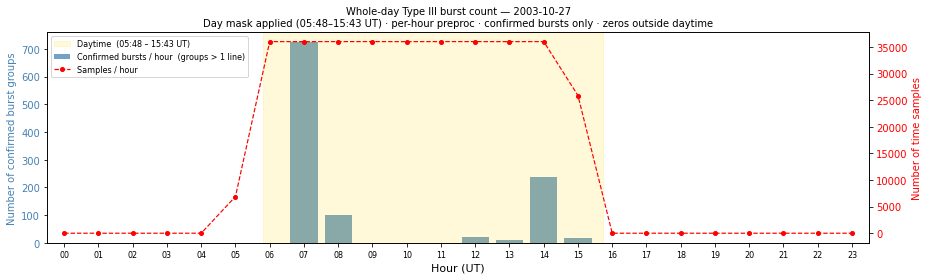

In [9]:
#  Rebuild per-hour arrays from the results list ─────────────────────────────
# (redundant if the loop above ran without interruption, but safe to recompute)
bursts_per_hour  = np.array([r["bursts"]  for r in hourly_results], dtype=int)
samples_per_hour = np.array([r["samples"] for r in hourly_results], dtype=int)

#  Sunrise / sunset as fractional hours (for axvspan) ───────────────────────
sunrise_h = sunrise_dt.hour + sunrise_dt.minute / 60
sunset_h  = sunset_dt.hour  + sunset_dt.minute  / 60

# Plot ────────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

# Bar chart — confirmed bursts (left axis)
ax1.bar(
    range(24), bursts_per_hour,
    color='steelblue', alpha=0.75,
    label='Confirmed bursts / hour  (groups > 1 line)'
)

# Line chart — samples (right axis)
ax2.plot(
    range(24), samples_per_hour,
    'r--o', ms=4, lw=1.2,
    label='Samples / hour'
)

# Shade daytime window
ax1.axvspan(
    sunrise_h, sunset_h,
    color='gold', alpha=0.15,
    label=f'Daytime  ({sunrise_str} – {sunset_str} UT)'
)

# Axis labels and formatting
ax1.set_xlabel('Hour (UT)', fontsize=11)
ax1.set_ylabel('Number of confirmed burst groups', color='steelblue', fontsize=10)
ax2.set_ylabel('Number of time samples',           color='red',       fontsize=10)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='red')
ax1.set_xticks(range(24))
ax1.set_xticklabels([f"{h:02d}" for h in range(24)], fontsize=8)
ax1.set_xlim(-0.5, 23.5)

obs_date = t_fits[0].strftime("%Y-%m-%d")
ax1.set_title(
    f'Whole-day Type III burst count — {obs_date}\n'
    f'Day mask applied ({sunrise_str}–{sunset_str} UT) · '
    f'per-hour preproc · confirmed bursts only · zeros outside daytime',
    fontsize=10
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()